In [1]:
import albumentations as A
import cv2
from matplotlib import pyplot as plt

c:\Users\Memit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(image)

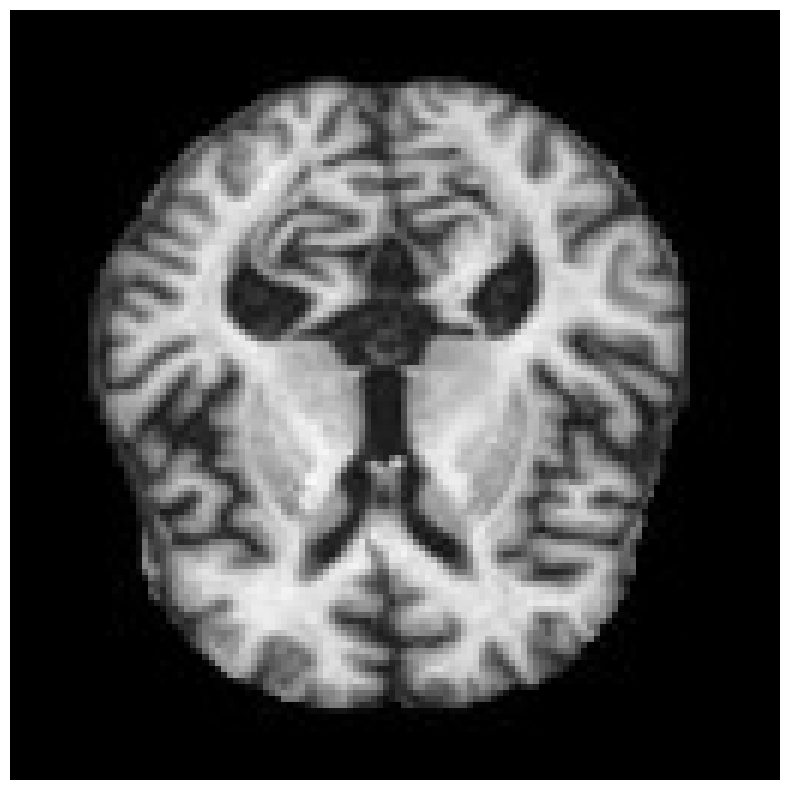

In [3]:
image = cv2.imread(r"C:\Users\Memit\Desktop\Final\Medikal\moderate_28.jpg", cv2.IMREAD_COLOR_RGB)
visualize(image)

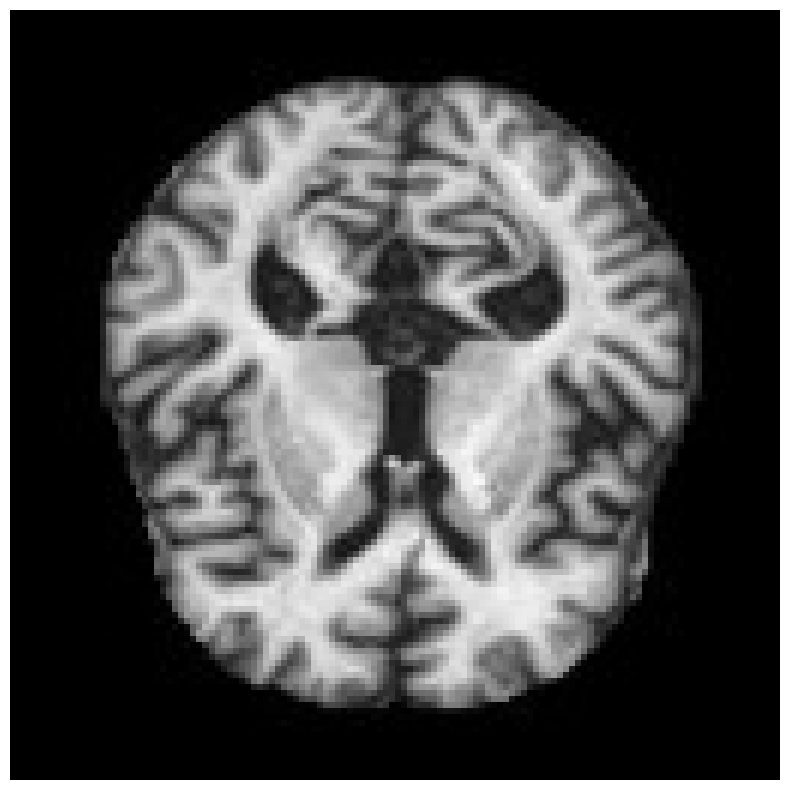

In [4]:
transform = A.HorizontalFlip(p=0.5)
transform.set_random_seed(137)

augmented_image = transform(image=image)["image"]
visualize(augmented_image)

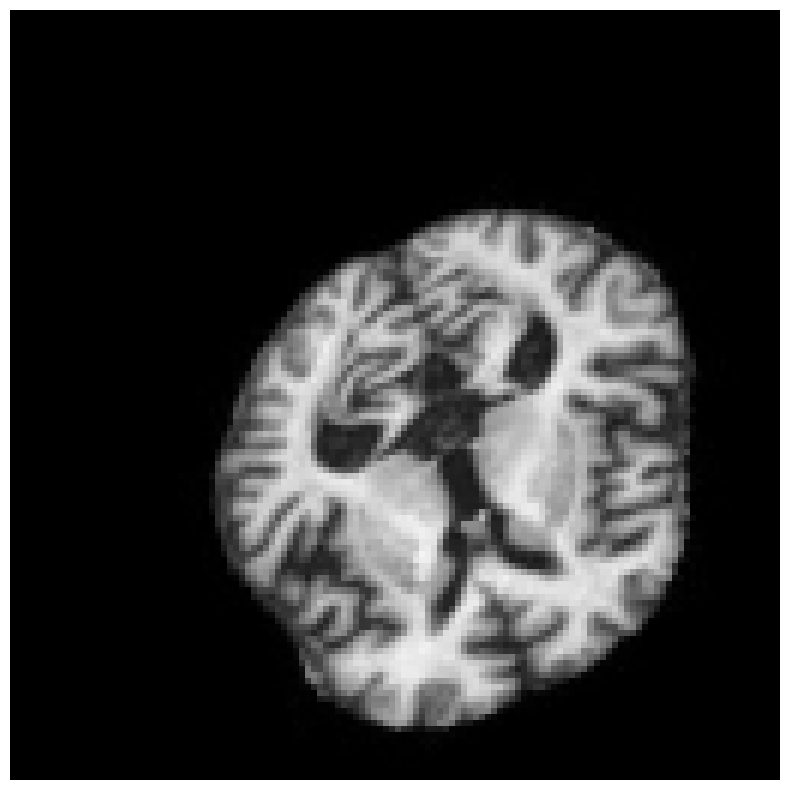

In [5]:
transform = A.Affine(p=0.5, scale=0.8, shear=5, translate_percent=0.1, rotate=20)
transform.set_random_seed(137)
augmented_image = transform(image=image)["image"]
visualize(augmented_image)

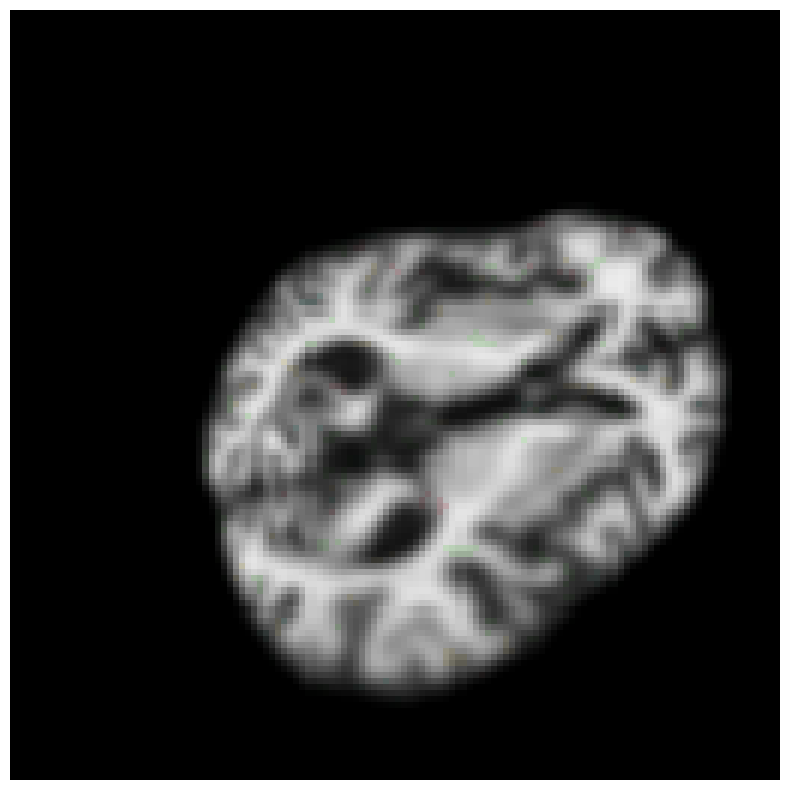

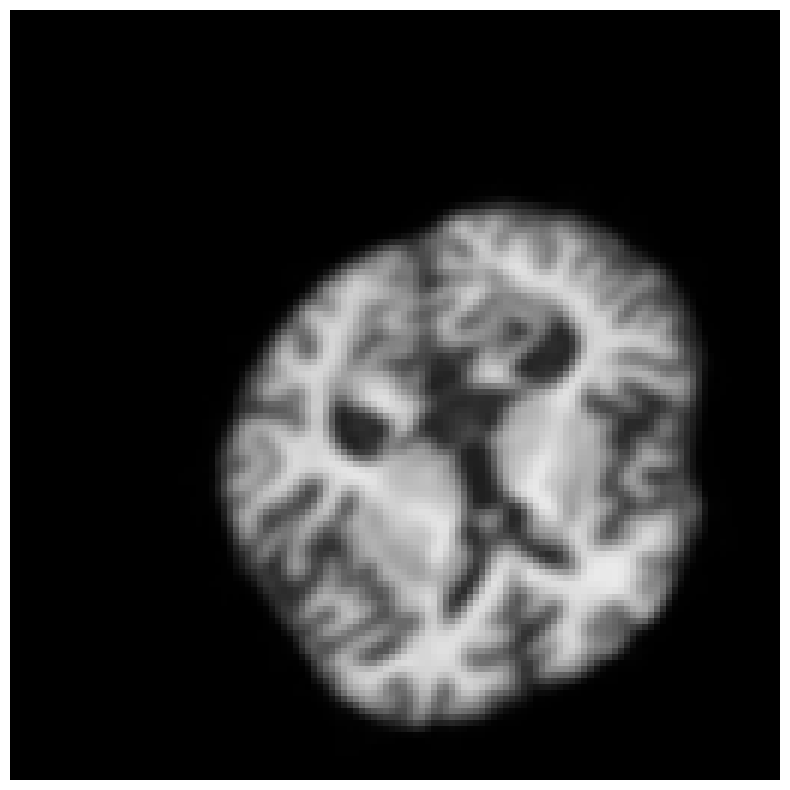

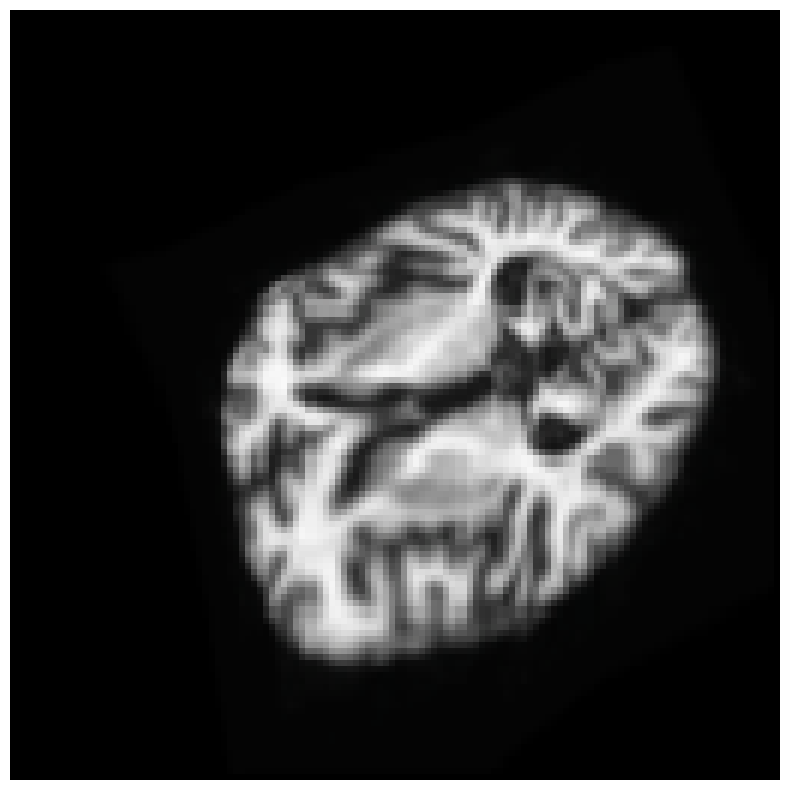

In [6]:
transform = A.Compose(
    [
        A.CLAHE(),
        A.RandomRotate90(),
        A.Transpose(),
        A.Affine(rotate=20, scale=0.8, shear=5, translate_percent=0.1, p=1),
        A.Blur(blur_limit=3),
        A.OpticalDistortion(),
        A.GridDistortion(),
        A.HueSaturationValue(),
    ],
    strict=True,
    seed=137,
)

augmented1 = transform(image=image)["image"]
augmented2 = transform(image=image)["image"]
augmented3 = transform(image=image)["image"]

visualize(augmented1)
visualize(augmented2)
visualize(augmented3)

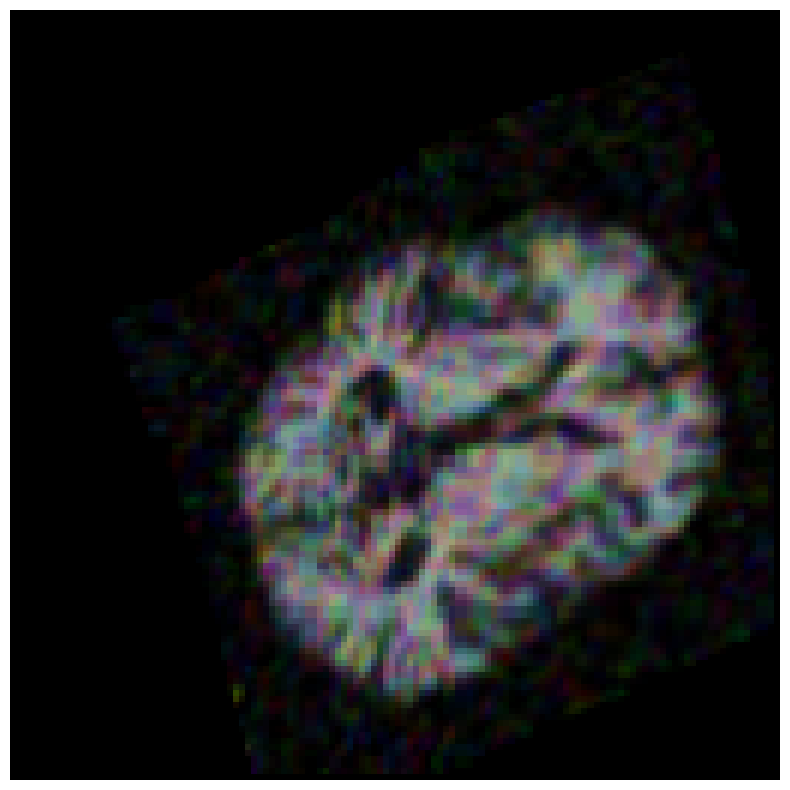

In [7]:
transform = A.Compose(
    [
        A.RandomRotate90(),
        A.Transpose(),
        A.GaussNoise(),
        A.OneOf(
            [
                A.MotionBlur(p=0.2),
                A.MedianBlur(blur_limit=3, p=0.1),
                A.Blur(blur_limit=3, p=0.1),
            ],
            p=0.2,
        ),
        A.Affine(rotate=20, scale=0.8, shear=5, translate_percent=0.1, p=0.2),
        A.OneOf(
            [
                A.OpticalDistortion(p=0.3),
                A.GridDistortion(p=0.1),
            ],
            p=0.2,
        ),
        A.OneOf(
            [
                A.CLAHE(clip_limit=2),
                A.RandomBrightnessContrast(),
            ],
            p=0.3,
        ),
        A.HueSaturationValue(p=0.3),
    ],
    strict=True,
    seed=137,
)

augmented_image = transform(image=image)["image"]
visualize(augmented_image)